# PCE Metamodeling for Heat Tranfer Problems

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from UQpy.distributions import Uniform, Normal, JointIndependent
from UQpy.surrogates import *

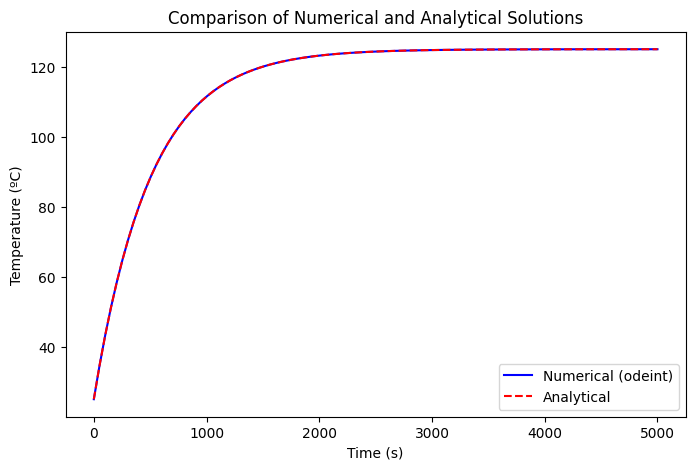

In [4]:
def heat_transfer_model(T, t, L, Cp, q, h, T_inf):
    dTdt = (q - h * (T - T_inf)) / (L * Cp)
    return dTdt

def analytical_solution(t, T0, L, x):
    q, Cp, h, T_inf = x
    tau = L * Cp / h  # Characteristic time constant
    T_eq = (q + h * T_inf) / h  # Equilibrium temperature
    r = T_eq + (T0 - T_eq) * np.exp(-t / tau)
    return r

L = 0.002            # Comprimento da placa
Cp = 2.5 * 10 ** 6   # Calor específico
q = 1000.0           # Fluxo de calor imposto
h = 10               # Coeficiente de convecção
T_inf = 25.0         # Temperatura ambiente
T_ini = 25.0         # Temperatura inicial
T0 = 25
x_t = [q, Cp, h, T_inf]

t = np.linspace(0, 5000, 100)

T_numerical = odeint(heat_transfer_model, T0, t, args=(L, Cp, q, h, T_inf))
T_numerical = T_numerical.flatten()

T_analytical = analytical_solution(t, T0, L, x_t)

plt.figure(figsize=(8, 5))
plt.plot(t, T_numerical, 'b-', label='Numerical (odeint)')
plt.plot(t, T_analytical, 'r--', label='Analytical')
plt.xlabel('Time (s)')
plt.ylabel('Temperature (ºC)')
plt.legend()
plt.title('Comparison of Numerical and Analytical Solutions')
plt.show()

In [5]:
np.random.seed(1)

# Construção do metamodelo

In [12]:
dist_q    = Uniform(loc = 100, scale=1100)
dist_Cp   = Uniform(loc = 1.0*10**6, scale = 3*10**6)
dist_h    = Uniform(loc = 5, scale=20)
dist_Tinf = Uniform(loc = 5, scale = 100)

marg = [dist_q, dist_Cp, dist_h, dist_Tinf]

joint = JointIndependent(marginals=marg)

n_samples = 1000
xx = joint.rvs(n_samples)

y = []
for i in range(n_samples):
    y.append(analytical_solution(t, T0, L, xx[i,:]))
    yy = np.array(y)

yy

array([[ 25.        ,  32.64377552,  38.31934843, ...,  54.68561468,
         54.68561468,  54.68561468],
       [ 25.        ,  30.62009863,  35.67012171, ...,  80.40410065,
         80.40427606,  80.40443367],
       [ 25.        ,  36.31717677,  44.21232416, ...,  62.42764178,
         62.42764178,  62.42764178],
       ...,
       [ 25.        ,  42.44600177,  52.66417758, ...,  67.10989297,
         67.10989297,  67.10989297],
       [ 25.        ,  46.66511617,  60.73785445, ...,  86.82216759,
         86.82216759,  86.82216759],
       [ 25.        ,  34.3123357 ,  42.80569011, ..., 130.87312814,
        130.87436142, 130.87548623]])

In [7]:
max_degree = 8
polynomial_basis = TotalDegreeBasis(joint, max_degree)

least_squares = LeastSquareRegression()
pce_metamodel = PolynomialChaosExpansion(polynomial_basis=polynomial_basis, regression_method=least_squares)
pce_metamodel.fit(xx, yy)

In [8]:
print("xx shape:", xx.shape)  # (1000, 5)
print("yy shape:", yy.shape)  # (1000, 2000)

xx shape: (1000, 4)
yy shape: (1000, 100)


In [9]:
n_samples = 1000
x_val = joint.rvs(n_samples)

y = []
for i in range(n_samples):
    y.append(analytical_solution(t, T0, L, x_val[i,:]))
    y_val = np.array(y)

y_val_pce = pce_metamodel.predict(x_val)

In [10]:
y_val_pce

array([[ 25.        ,  28.49657224,  31.50434619, ...,  49.96349517,
         49.96335478,  49.96320819],
       [ 25.        ,  34.04161083,  41.61187208, ...,  80.50833144,
         80.50845602,  80.5085821 ],
       [ 25.        ,  29.81863072,  32.64996984, ...,  36.52915718,
         36.53249654,  36.53574521],
       ...,
       [ 25.        ,  46.07646002,  61.97008119, ..., 110.68858335,
        110.68832491, 110.68810046],
       [ 25.        ,  38.16744216,  49.74606758, ..., 134.15497793,
        134.15527739, 134.15556393],
       [ 25.        ,  39.01665537,  50.58966621, ..., 105.4009903 ,
        105.40096206, 105.40093423]])

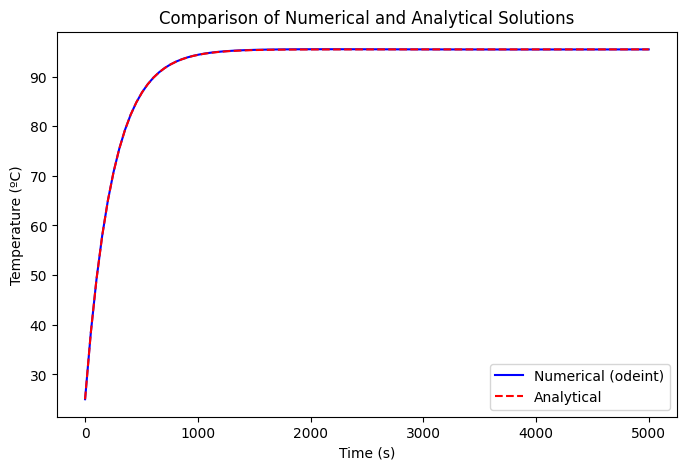

In [11]:
T_analytical_val = analytical_solution(t, T0, L, x_val[55,:])
T_pce = pce_metamodel.predict(x_val[55,:])[0]

plt.figure(figsize=(8, 5))
plt.plot(t, T_pce, 'b-', label='Numerical (odeint)')
plt.plot(t, T_analytical_val, 'r--', label='Analytical')
plt.xlabel('Time (s)')
plt.ylabel('Temperature (ºC)')
plt.legend()
plt.title('Comparison of Numerical and Analytical Solutions')
plt.show()

# Validação do metamodelo

In [27]:
x_validation = joint.rvs(300)

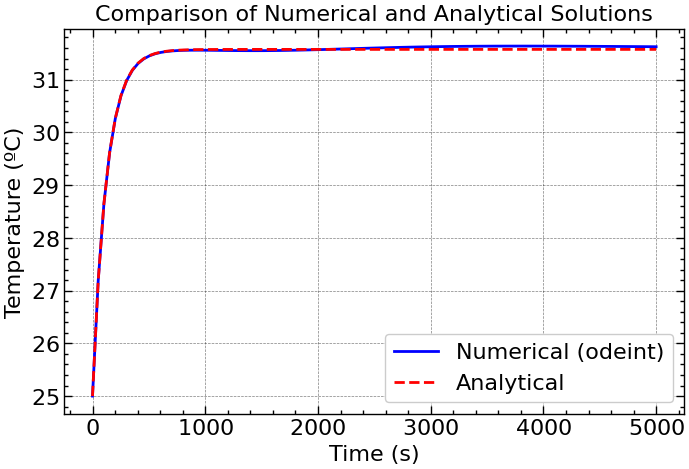

In [29]:
T_analytical_val = analytical_solution(t, T0, L, x_validation[5,:])
T_pce = pce_metamodel.predict(x_validation[5,:])[0]

plt.figure(figsize=(8, 5))
plt.plot(t, T_pce, 'b-', label='Numerical (odeint)')
plt.plot(t, T_analytical_val, 'r--', label='Analytical')
plt.xlabel('Time (s)')
plt.ylabel('Temperature (ºC)')
plt.legend()
plt.title('Comparison of Numerical and Analytical Solutions')
plt.show()

In [18]:
y_validation = pce_metamodel.predict(x_validation)

y_val_full = []
for i in range(len(x_validation)):
    y_val_full.append(analytical_solution(t, T0, L, x_validation[i,:]))
    y_val_resp = np.array(y_val_full)

In [19]:
y_val_test_p = y_validation.max(axis=1)
y_val_resp_p = y_val_resp.max(axis=1)

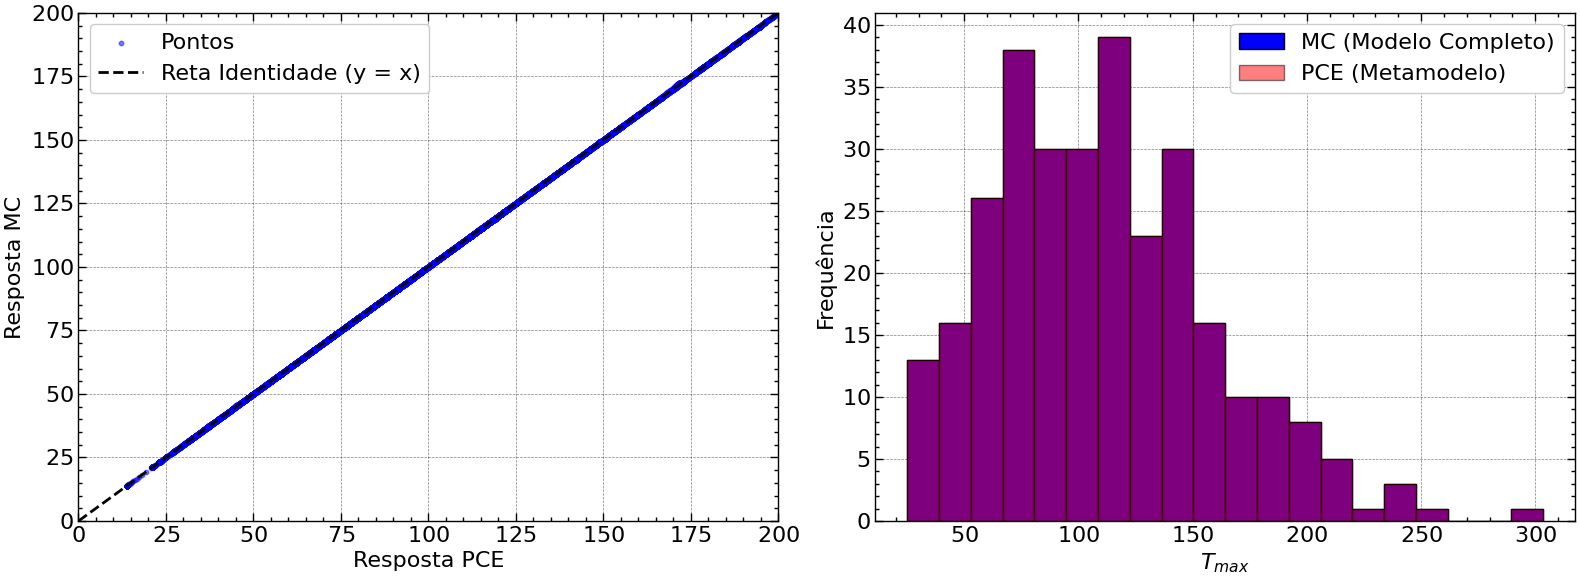

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  

axes[0].scatter(y_validation, y_val_resp, color='blue', alpha=0.5, s=10, label='Pontos')
axes[0].plot([0, 200], [0, 200], color='black', linestyle='--', label='Reta Identidade (y = x)')
axes[0].set_xlim(0, 200)
axes[0].set_ylim(0, 200)
axes[0].set_xlabel('Resposta PCE')
axes[0].set_ylabel('Resposta MC')
axes[0].legend()
axes[0].grid(True)

axes[1].hist(y_val_test_p, bins=20, color='blue', edgecolor='black', alpha=1, label='MC (Modelo Completo)')
axes[1].hist(y_val_resp_p, bins=20, color='red', edgecolor='black', alpha=0.5, label='PCE (Metamodelo)')
axes[1].set_xlabel('$T_{max}$')
axes[1].set_ylabel('Frequência')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()

plt.show()